## 最近邻方法的实际应用 ##
在某些案例中，k-NN 可以作为一个模型的基线。
在 Kaggle 竞赛中，k-NN 常常用于构建元特征（即 k-NN 的预测结果作为其他模型的输入），或用于堆叠/混合。
最近邻方法还可以扩展到推荐系统等任务中。
在大型数据集上，常常使用逼近方法搜索最近邻。
k-NN 分类/回归的效果取决于一些参数：

邻居数 k。
样本之间的距离度量（常见的包括 Hamming，欧几里得，余弦和 Minkowski 距离）。注意，大部分距离要求数据在同一尺度下，例如「薪水」特征的数值在千级，「年龄」特征的数值却在百级，如果直接将他们丢进最近邻模型中，「年龄」特征就会受到比较大的影响。
邻居的权重（每个邻居可能贡献不同的权重，例如，样本越远，权重越低）。
scikit-learn 的 KNeighborsClassifier 类
sklearn.neighbors.KNeighborsClassifier 类的主要参数为：

weights：可设为 uniform（所有权重相等），distance（权重和到测试样本的距离成反比），或任何其他用户自定义的函数。
algorithm（可选）：可设为 brute、ball_tree、KD_tree、auto。若设为 brute，通过训练集上的网格搜索来计算每个测试样本的最近邻；若设为 ball_tree 或 KD_tree，样本间的距离储存在树中，以加速寻找最近邻；若设为 auto，将基于训练集自动选择合适的寻找最近邻的方法。
leaf_size（可选）：若寻找最近邻的算法是 BallTree 或 KDTree，则切换为网格搜索所用的阈值。
metric：可设为 minkowski、manhattan、euclidean、chebyshev 或其他。


## 在客户离网率预测任务中使用决策树和最近邻方法 ##

In [1]:
import pandas as pd
df = pd.read_csv(
    'https://labfile.oss.aliyuncs.com/courses/1283/telecom_churn.csv')
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
df['International plan'] = pd.factorize(df['International plan'])[0]
df['Voice mail plan'] = pd.factorize(df['Voice mail plan'])[0]
df['Churn'] = df['Churn'].astype('int')
states = df['State']
y = df['Churn']
df.drop(['State', 'Churn'], axis=1, inplace=True)
df.head()


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,415,0,0,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,415,0,0,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,415,0,1,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,408,1,1,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,415,1,1,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
X_train, X_holdout, y_train, y_holdout = train_test_split(df.values, y, test_size=0.3,
                                                          random_state=17)

tree = DecisionTreeClassifier(max_depth=5, random_state=17)
knn = KNeighborsClassifier(n_neighbors=10)

tree.fit(X_train, y_train)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=10)

In [4]:
from sklearn.metrics import accuracy_score

tree_pred = tree.predict(X_holdout)
print('tree:',accuracy_score(y_holdout, tree_pred))
knn_pred = knn.predict(X_holdout)
print('knn:',accuracy_score(y_holdout, knn_pred))


tree: 0.94
knn: 0.881


In [5]:
from sklearn.model_selection import GridSearchCV, cross_val_score

tree_params = {'max_depth': range(5, 7),
               'max_features': range(16, 18)}

tree_grid = GridSearchCV(tree, tree_params,
                         cv=5, n_jobs=-1, verbose=True)

tree_grid.fit(X_train, y_train)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=5, random_state=17),
             n_jobs=-1,
             param_grid={'max_depth': range(5, 7),
                         'max_features': range(16, 18)},
             verbose=True)

In [6]:
tree_grid.best_params_

{'max_depth': 6, 'max_features': 17}

In [7]:
tree_grid.best_score_


0.94257014456259

In [8]:
accuracy_score(y_holdout, tree_grid.predict(X_holdout))


0.946

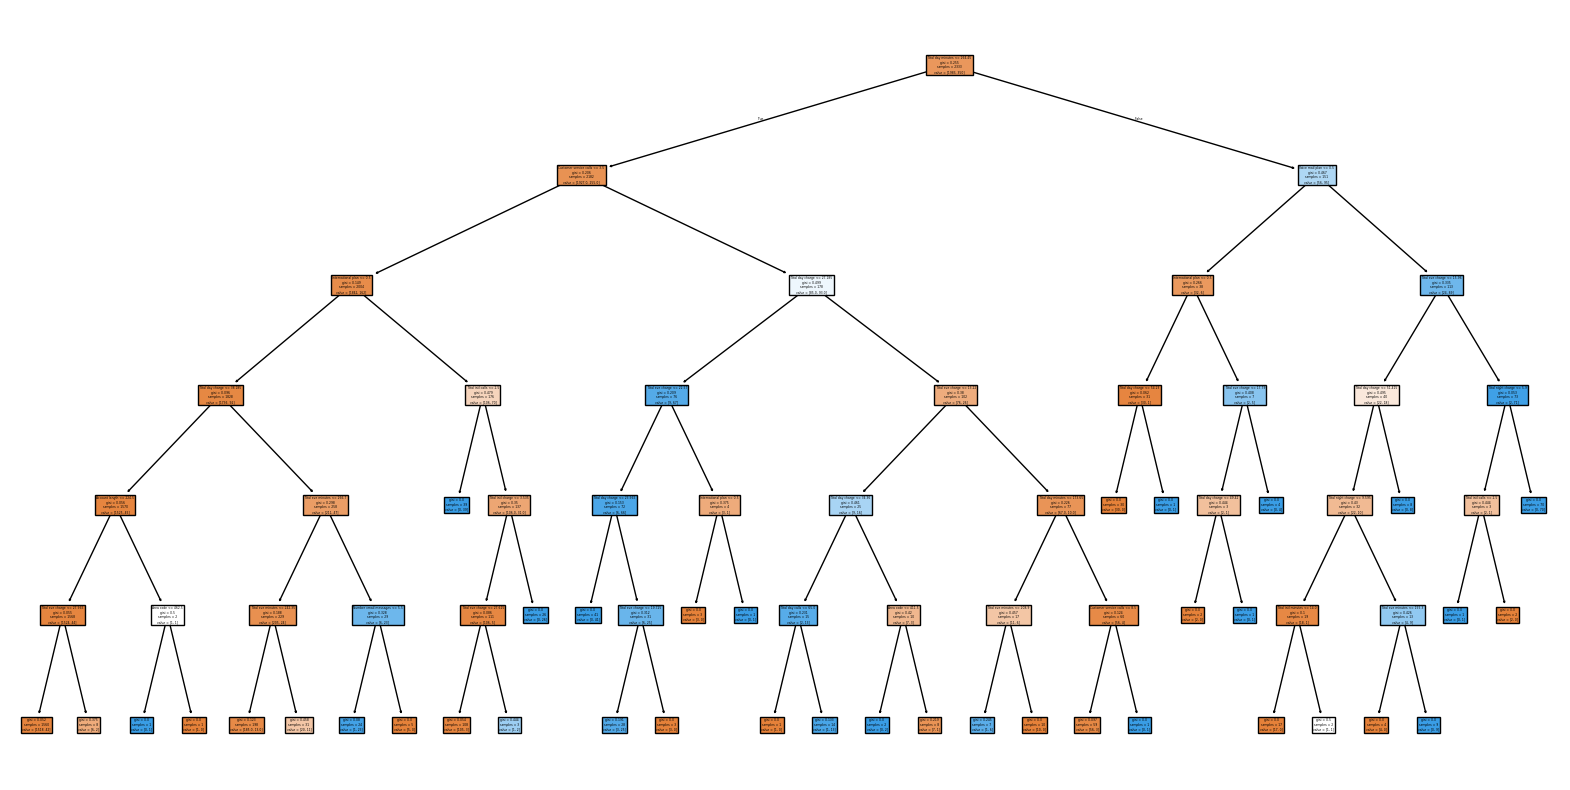

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_grid.best_estimator_, 
            feature_names=df.columns.tolist(),  
            filled=True)
plt.show()


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),   # 第一步：数据标准化
    ('knn', KNeighborsClassifier(n_jobs=-1))  # 第二步：KNN分类
])

knn_params = {
    'knn__n_neighbors':range(6,8)
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_params,
    cv=5,
    n_jobs=-1,
    verbose=True
)

knn_grid.fit(X_train,y_train)


Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn',
                                        KNeighborsClassifier(n_jobs=-1))]),
             n_jobs=-1, param_grid={'knn__n_neighbors': range(6, 8)},
             verbose=True)

In [13]:
knn_grid.best_params_,knn_grid.best_score_

({'knn__n_neighbors': 7}, 0.8859867109023905)

In [14]:
accuracy_score(y_holdout,knn_grid.predict(X_holdout))

0.89

In [15]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100,n_jobs=-1,random_state=17)

np.mean(cross_val_score(forest,X_train,y_train,cv=5))

0.9494233119813256

In [16]:
forest_params = {'max_depth': range(8, 10),
               'max_features': range(5, 7)}
forest_grid = GridSearchCV(forest, forest_params,
                         cv=5, n_jobs=-1, verbose=True)
forest_grid.fit(X_train, y_train)
forest_grid.best_params_, forest_grid.best_score_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


({'max_depth': 9, 'max_features': 6}, 0.9511372931045574)

In [17]:
accuracy_score(y_holdout, forest_grid.predict(X_holdout))

0.953

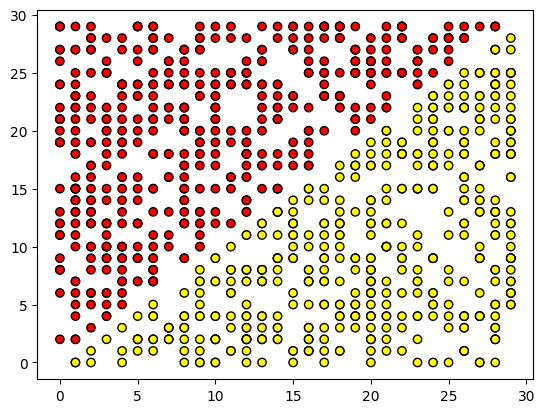

In [19]:
def form_linearly_separable_data(n=500, x1_min=0, x1_max=30,
                                 x2_min=0, x2_max=30):
    data, target = [], []
    for i in range(n):
        x1 = np.random.randint(x1_min, x1_max)
        x2 = np.random.randint(x2_min, x2_max)
        if np.abs(x1 - x2) > 0.5:
            data.append([x1, x2])
            target.append(np.sign(x1 - x2))
    return np.array(data), np.array(target)


X, y = form_linearly_separable_data()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', edgecolors='black')
plt.show()

In [20]:
tree = DecisionTreeClassifier(random_state=17).fit(X, y)

In [21]:
def get_grid(data, step=0.02):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    return xx, yy

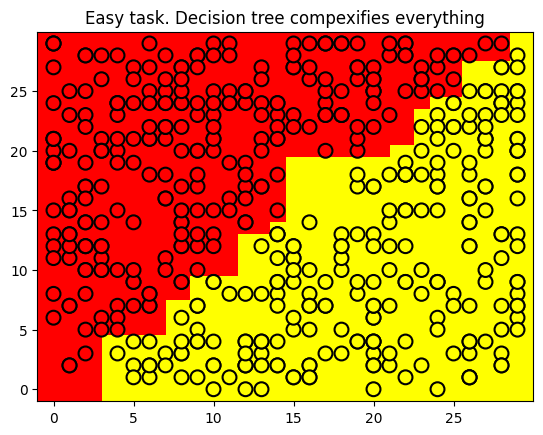

In [23]:
xx, yy = get_grid(X)
predicted = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap='autumn')
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap='autumn', edgecolors='black', linewidth=1.5)
plt.title('Easy task. Decision tree compexifies everything')
plt.show()

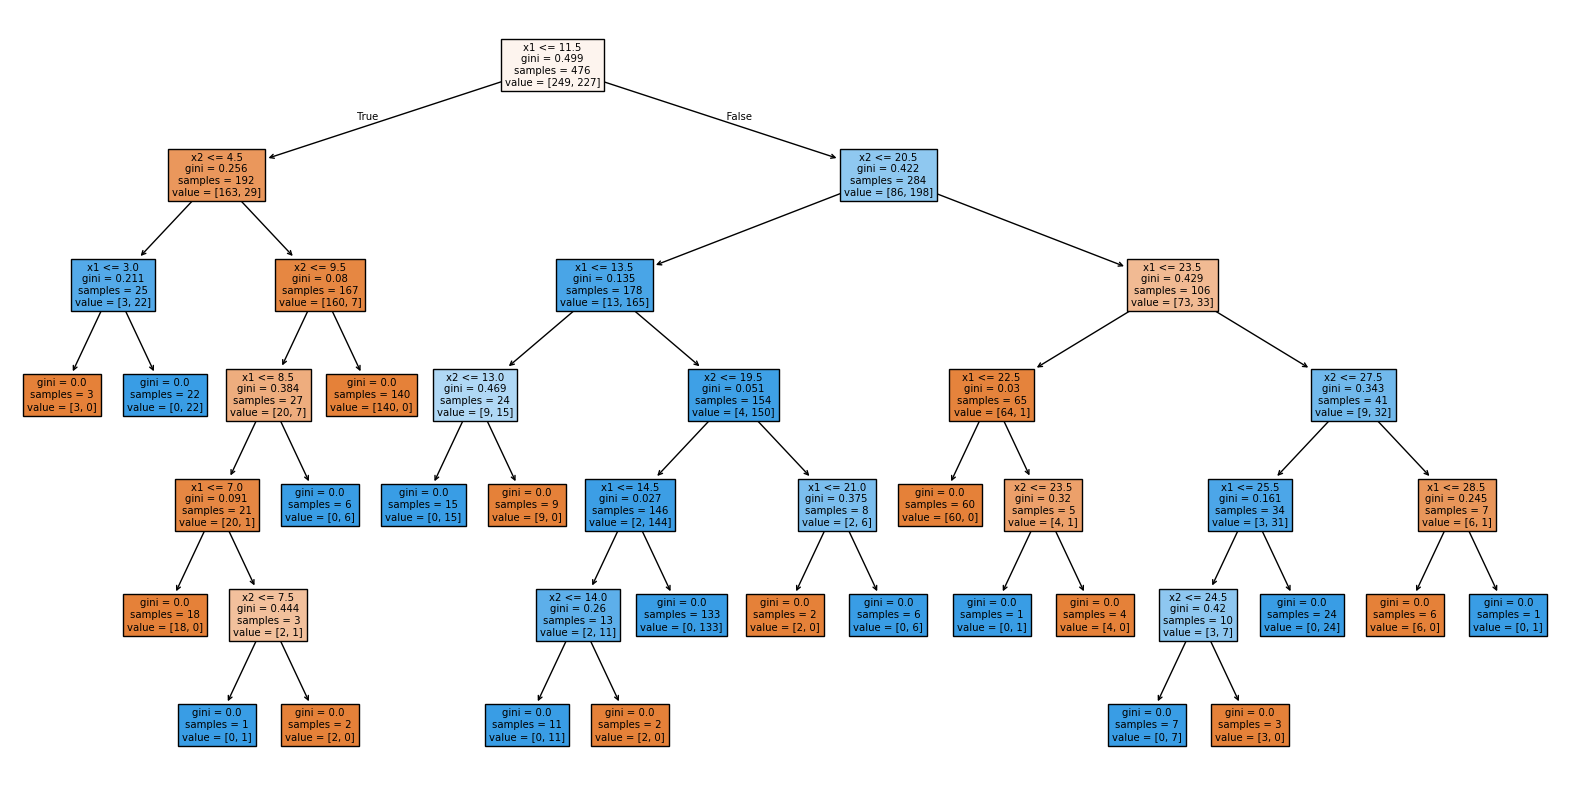

In [24]:
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=['x1', 'x2'], filled=True)

plt.show()

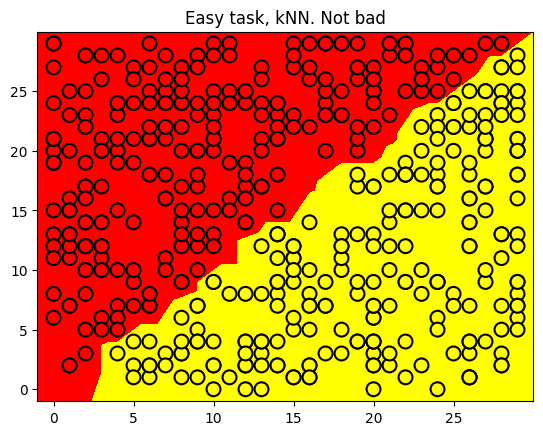

In [25]:
knn = KNeighborsClassifier(n_neighbors=1).fit(X, y)

xx, yy = get_grid(X)
predicted = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap='autumn')
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap='autumn', edgecolors='black', linewidth=1.5)
plt.title('Easy task, kNN. Not bad')
plt.show()

## 在 MNIST 手写数字识别任务中应用决策树和 k-NN ##

In [26]:
from sklearn.datasets import load_digits

data = load_digits()
X, y = data.data, data.target

X[0, :].reshape([8, 8])

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

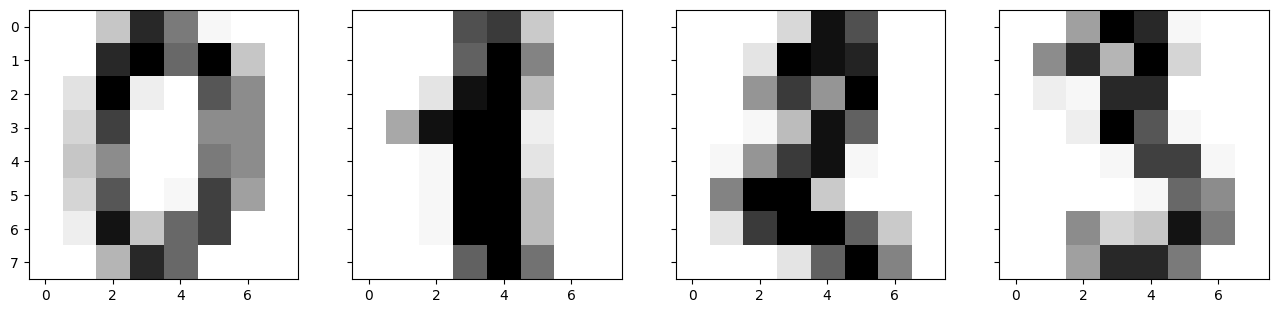

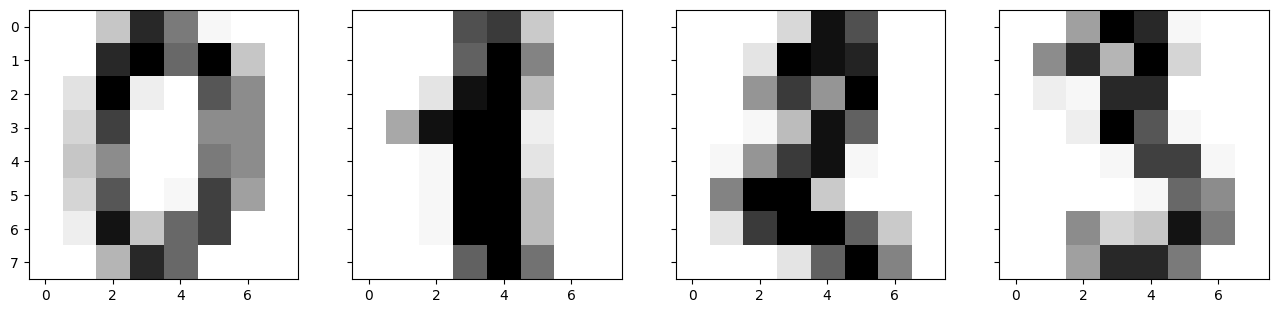

In [28]:
f, axes = plt.subplots(1, 4, sharey=True, figsize=(16, 6))
for i in range(4):
    axes[i].imshow(X[i, :].reshape([8, 8]), cmap='Greys')
plt.show()

In [29]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=17)

In [33]:
tree = DecisionTreeClassifier(max_depth=5, random_state=17)
knn_pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=10))])

tree.fit(X_train, y_train)
knn_pipe.fit(X_train, y_train)


tree_pred = tree.predict(X_holdout)
knn_pred = knn_pipe.predict(X_holdout)
print("kNN Accuracy:", accuracy_score(y_holdout, knn_pred))
print("Decision Tree Accuracy:", accuracy_score(y_holdout, tree_pred))  # (0.976, 0.666)
# 随机参数

kNN Accuracy: 0.975925925925926
Decision Tree Accuracy: 0.6666666666666666


In [34]:
tree_params = {'max_depth': [10, 20, 30],
               'max_features': [30, 50, 64]}

tree_grid = GridSearchCV(tree, tree_params,
                         cv=5, n_jobs=-1, verbose=True)

tree_grid.fit(X_train, y_train)

tree_grid.best_params_, tree_grid.best_score_

Fitting 5 folds for each of 9 candidates, totalling 45 fits


({'max_depth': 10, 'max_features': 50}, 0.8568203376968316)

In [37]:
print("kNN Accuracy:", np.mean(cross_val_score(KNeighborsClassifier(
    n_neighbors=1), X_train, y_train, cv=5)))

print("Random Forest Accuracy:", np.mean(cross_val_score(RandomForestClassifier(
    random_state=17), X_train, y_train, cv=5)))

kNN Accuracy: 0.9864858028204642
Random Forest Accuracy: 0.9753462341111744


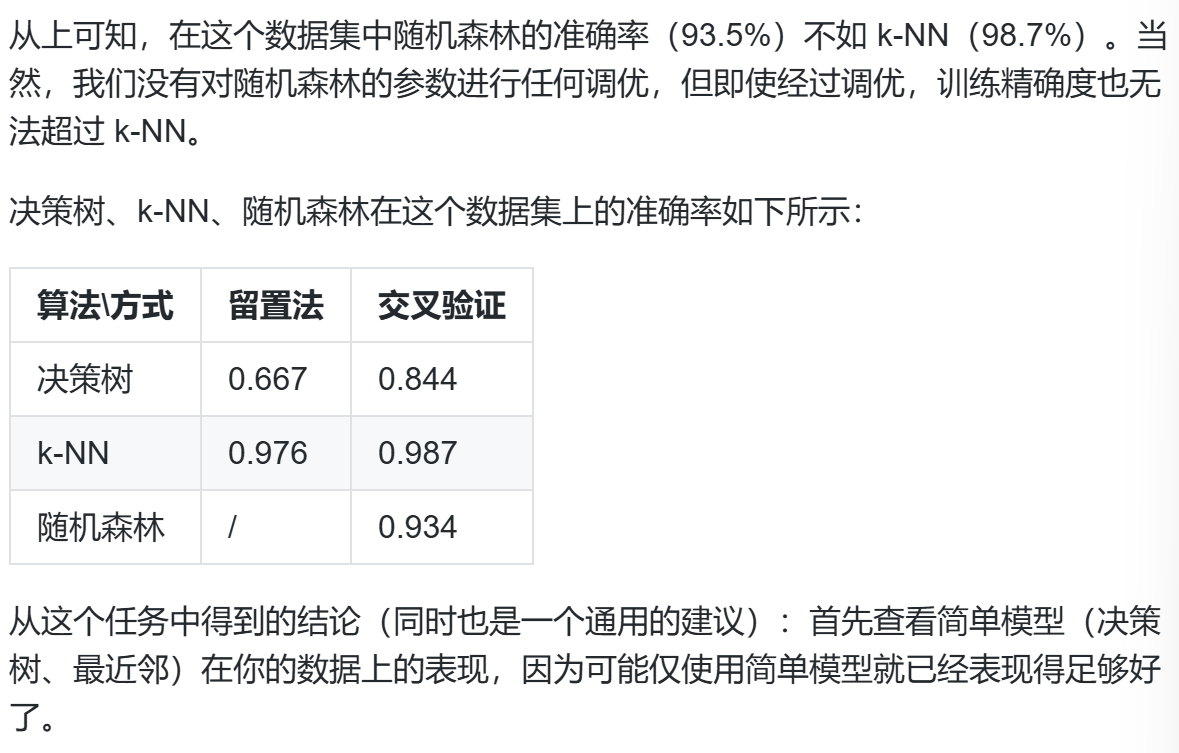

## 最近邻方法的复杂情形 ##

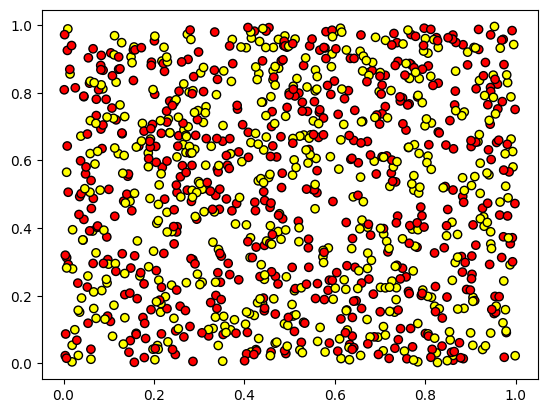

In [45]:
def form_noisy_data(n_obj=1000, n_feat=100, random_seed=17):
    np.seed = random_seed
    y = np.random.choice([-1, 1], size=n_obj)
    # 第一个特征与目标成比例
    x1 = 0.3 * y
    # 其他特征为噪声
    x_other = np.random.random(size=[n_obj, n_feat - 1])
    return np.hstack([x1.reshape([n_obj, 1]), x_other]), y


X, y = form_noisy_data()
plt.scatter(X[:, 1], X[:, 2], c=y, cmap='autumn', edgecolors='black')
plt.show()

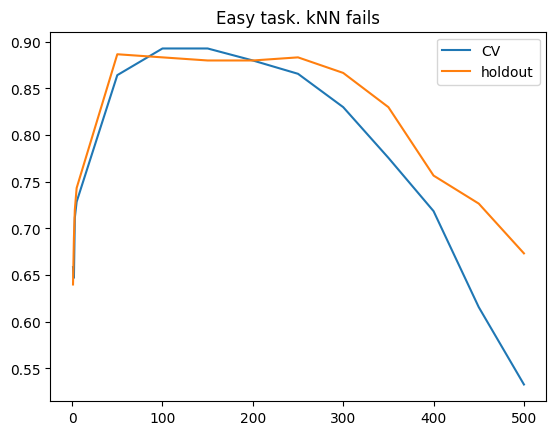

In [39]:
from sklearn.model_selection import cross_val_score
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=17)


cv_scores, holdout_scores = [], []
n_neighb = [1, 2, 3, 5] + list(range(50, 550, 50))

for k in n_neighb:

    knn_pipe = Pipeline([('scaler', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=k))])
    cv_scores.append(np.mean(cross_val_score(
        knn_pipe, X_train, y_train, cv=5)))
    knn_pipe.fit(X_train, y_train)
    holdout_scores.append(accuracy_score(
        y_holdout, knn_pipe.predict(X_holdout)))

plt.plot(n_neighb, cv_scores, label='CV')
plt.plot(n_neighb, holdout_scores, label='holdout')
plt.title('Easy task. kNN fails')
plt.legend()
plt.show()

In [46]:
tree = DecisionTreeClassifier(random_state=17, max_depth=1)
tree_cv_score = np.mean(cross_val_score(tree, X_train, y_train, cv=5))
tree.fit(X_train, y_train)
tree_holdout_score = accuracy_score(y_holdout, tree.predict(X_holdout))
print('Decision tree. CV: {}, holdout: {}'.format(
    tree_cv_score, tree_holdout_score))

Decision tree. CV: 1.0, holdout: 1.0


## 决策树的优劣 ##
#### 优势 ####

生成容易理解的分类规则，这一属性称为模型的可解释性。例如它生成的规则可能是「如果年龄不满 25 岁，并对摩托车感兴趣，那么就拒绝发放贷款」。
很容易可视化，即模型本身（树）和特定测试对象的预测（穿过树的路径）可以「被解释」。
训练和预测的速度快。
较少的参数数目。
支持数值和类别特征。
#### 劣势： ####

决策树对输入数据中的噪声非常敏感，这削弱了模型的可解释性。
决策树构建的边界有其局限性：它由垂直于其中一个坐标轴的超平面组成，在实践中比其他方法的效果要差。
我们需要通过剪枝、设定叶节点的最小样本数、设定树的最大深度等方法避免过拟合。
不稳定性，数据的细微变动都会显著改变决策树。这一问题可通过决策树集成方法来处理（以后的实验会介绍）。
搜索最佳决策树是一个「NP 完全」（NP-Complete）问题。了解什么是 NP-Complete 请点击  这里。实践中使用的一些推断方法，比如基于最大信息增益进行贪婪搜索，并不能保证找到全局最优决策树。
倘若数据中出现缺失值，将难以创建决策树模型。Friedman 的 CART 算法中大约 50% 的代码是为了处理数据中的缺失值（现在 sklearn 实现了这一算法的改进版本）。
这一模型只能内插，不能外推（随机森林和树提升方法也是如此）。也就是说，倘若你预测的对象在训练集所设置的特征空间之外，那么决策树就只能做出常数预测。比如，在我们的黄球和蓝球的例子中，这意味着模型将对所有位于 >19 或 <0 的球做出同样的预测。

## 最近邻方法的优劣 ##
#### 优势： ####

实现简单。
研究很充分。
通常而言，在分类、回归、推荐问题中第一个值得尝试的方法就是最近邻方法。
通过选择恰当的衡量标准或核，它可以适应某一特定问题。
#### 劣势： ####

和其他复合算法相比，这一方法速度较快。但是，现实生活中，用于分类的邻居数目通常较大（100-150），在这一情形下，k-NN 不如决策树快。
如果数据集有很多变量，很难找到合适的权重，也很难判定哪些特征对分类/回归不重要。
依赖于对象之间的距离度量，默认选项欧几里得距离常常是不合理的。你可以通过网格搜索参数得到良好的解，但在大型数据集上的耗时很长。
没有理论来指导我们如何选择邻居数，故而只能进行网格搜索（尽管基本上所有的模型，在对其超参数进行调整时都使用网格搜索的方法）。在邻居数较小的情形下，该方法对离散值很敏感，也就是说，有过拟合的倾向。
由于「维度的诅咒」，当数据集存在很多特征时它的表现不佳。